# Sync vs Async API Benchmark Analysis

Comparison of synchronous and asynchronous PostgreSQL access in the FastAPI application.

Benchmarks were executed with `oha` using:

- 5000 requests per run
- concurrency levels: 1, 5, 10, 20
- 3 rounds per endpoint and concurrency level
- identical Uvicorn server configuration
- `SelectorEventLoop`
- the same machine, database and dataset

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")

with open(RESULTS_DIR / "oha_sync.json", encoding="utf-8") as file:
    sync_data = json.load(file)

with open(RESULTS_DIR / "oha_async.json", encoding="utf-8") as file:
    async_data = json.load(file)

len(sync_data), len(async_data)

(72, 72)

In [10]:
def flatten_results(data):
    rows = []

    for result in data:
        metrics = result["oha"]["metrics"]
        latency = metrics["latency_ms"]

        rows.append({
            "label": result["label"],
            "endpoint": result["endpoint"],
            "concurrency": result["concurrency"],
            "round": result["round"],
            "requests": result["requests"],
            "rps": metrics["requests_per_sec"],
            "avg_ms": latency["mean"],
            "p50_ms": latency["p50"],
            "p95_ms": latency["p95"],
            "p99_ms": latency["p99"],
            "success_rate": metrics["success_rate"],
        })

    return pd.DataFrame(rows)


sync_df = flatten_results(sync_data)
async_df = flatten_results(async_data)

df = pd.concat([sync_df, async_df], ignore_index=True)

df.head(6)

,label,endpoint,concurrency,round,requests,rps,avg_ms,p50_ms,p95_ms,p99_ms,success_rate
0,sync,/health,1,1,5000,7890.172585,0.126,0.112,0.183,0.217,1.0
1,sync,/health,1,2,5000,7978.414877,0.124,0.112,0.181,0.215,1.0
2,sync,/health,1,3,5000,8096.063354,0.122,0.111,0.179,0.209,1.0
3,sync,/health,5,1,5000,15654.709704,0.318,0.291,0.426,0.545,1.0
4,sync,/health,5,2,5000,16159.114274,0.308,0.288,0.409,0.500,1.0
5,sync,/health,5,3,5000,16020.208532,0.310,0.288,0.423,0.527,1.0


In [11]:
print("Rows:", len(df))
print()
print(df.groupby("label").size())
print()
print("Endpoints:", df["endpoint"].nunique())
print(
    "Concurrency levels:",
    sorted(df["concurrency"].astype(int).unique().tolist())
)

print(
    "Rounds:",
    sorted(df["round"].astype(int).unique().tolist())
)
print()
print("Minimum success rate:", df["success_rate"].min())

Rows: 144

label
async    72
sync     72
dtype: int64

Endpoints: 6
Concurrency levels: [1, 5, 10, 20]
Rounds: [1, 2, 3]

Minimum success rate: 1.0


In [22]:
summary = (
    df.groupby(["label", "endpoint", "concurrency"])
    .agg(
        rps_mean=("rps", "mean"),
        rps_std=("rps", "std"),
        avg_ms_mean=("avg_ms", "mean"),
        p95_ms_mean=("p95_ms", "mean"),
        p99_ms_mean=("p99_ms", "mean"),
    )
    .reset_index()
)

summary.head(5)

,label,endpoint,concurrency,rps_mean,rps_std,avg_ms_mean,p95_ms_mean,p99_ms_mean
0,async,/analytics/monthly-expenses,1,2190.117456,55.393879,0.455000,0.617333,0.734667
1,async,/analytics/monthly-expenses,5,4252.115611,272.597746,1.176000,1.620000,1.938333
2,async,/analytics/monthly-expenses,10,4538.155033,126.872193,2.198333,2.973000,3.838333
3,async,/analytics/monthly-expenses,20,4467.848398,31.740066,4.451333,5.472000,6.783333
4,async,/analytics/pareto-route-costs,1,813.974042,26.211724,1.227333,1.567333,1.753667


In [23]:
print("Rows after aggregation:", len(summary))

summary[
    summary["endpoint"] == "/analytics/monthly-expenses"
].sort_values(["concurrency", "label"]).reset_index(drop=True)

Rows after aggregation: 48


,label,endpoint,concurrency,rps_mean,rps_std,avg_ms_mean,p95_ms_mean,p99_ms_mean
0,async,/analytics/monthly-expenses,1,2190.117456,55.393879,0.455000,0.617333,0.734667
1,sync,/analytics/monthly-expenses,1,2877.706948,112.276430,0.346000,0.451667,0.513333
2,async,/analytics/monthly-expenses,5,4252.115611,272.597746,1.176000,1.620000,1.938333
3,sync,/analytics/monthly-expenses,5,3484.007573,42.403904,1.432333,1.915000,2.200667
4,async,/analytics/monthly-expenses,10,4538.155033,126.872193,2.198333,2.973000,3.838333
5,sync,/analytics/monthly-expenses,10,3434.336749,102.141122,2.906333,3.394333,3.746667
6,async,/analytics/monthly-expenses,20,4467.848398,31.740066,4.451333,5.472000,6.783333
7,sync,/analytics/monthly-expenses,20,3399.408393,89.643238,5.857333,6.708000,7.470000


In [24]:
comparison = summary.pivot(
    index=["endpoint", "concurrency"],
    columns="label",
    values=["rps_mean", "avg_ms_mean", "p95_ms_mean"],
)

comparison.columns = [
    f"{metric}_{label}"
    for metric, label in comparison.columns
]

comparison = comparison.reset_index()

comparison["rps_gain_pct"] = (
    (comparison["rps_mean_async"] - comparison["rps_mean_sync"])
    / comparison["rps_mean_sync"]
    * 100
)

comparison["avg_latency_improvement_pct"] = (
    (comparison["avg_ms_mean_sync"] - comparison["avg_ms_mean_async"])
    / comparison["avg_ms_mean_sync"]
    * 100
)

comparison["p95_improvement_pct"] = (
    (comparison["p95_ms_mean_sync"] - comparison["p95_ms_mean_async"])
    / comparison["p95_ms_mean_sync"]
    * 100
)

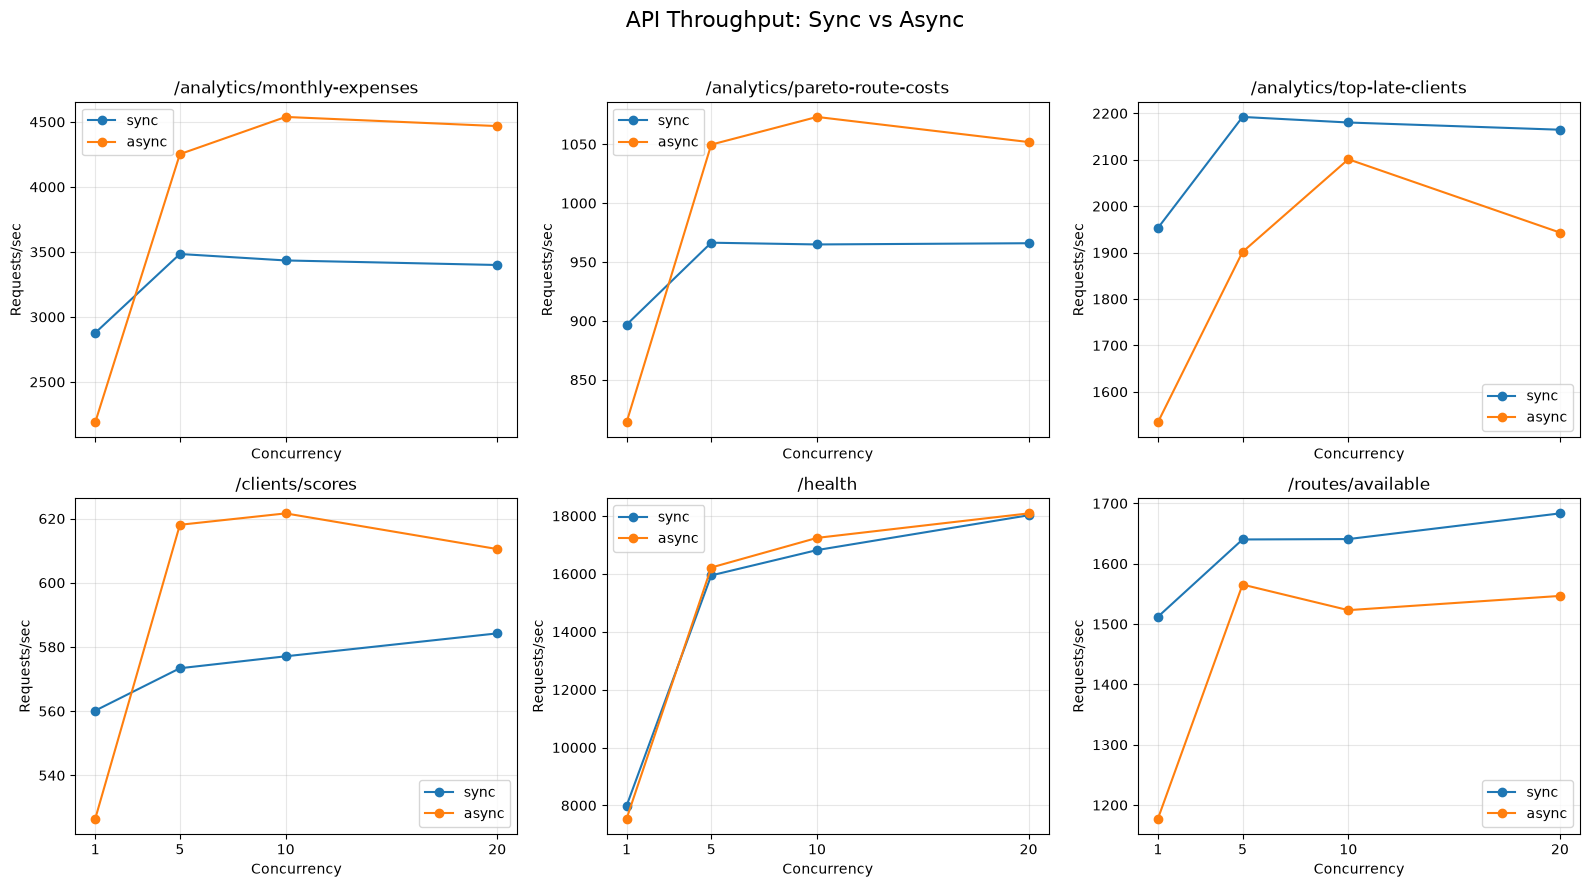

In [33]:
CHARTS_DIR = Path("charts")
CHARTS_DIR.mkdir(exist_ok=True)

endpoints = summary["endpoint"].unique()

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for ax, endpoint in zip(axes, endpoints):
    endpoint_data = summary[summary["endpoint"] == endpoint]

    for label in ["sync", "async"]:
        data = (
            endpoint_data[endpoint_data["label"] == label]
            .sort_values("concurrency")
        )

        ax.plot(
            data["concurrency"],
            data["rps_mean"],
            marker="o",
            label=label,
        )

    ax.set_title(endpoint)
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("Requests/sec")
    ax.set_xticks([1, 5, 10, 20])
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("API Throughput: Sync vs Async", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(
    CHARTS_DIR / "throughput.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

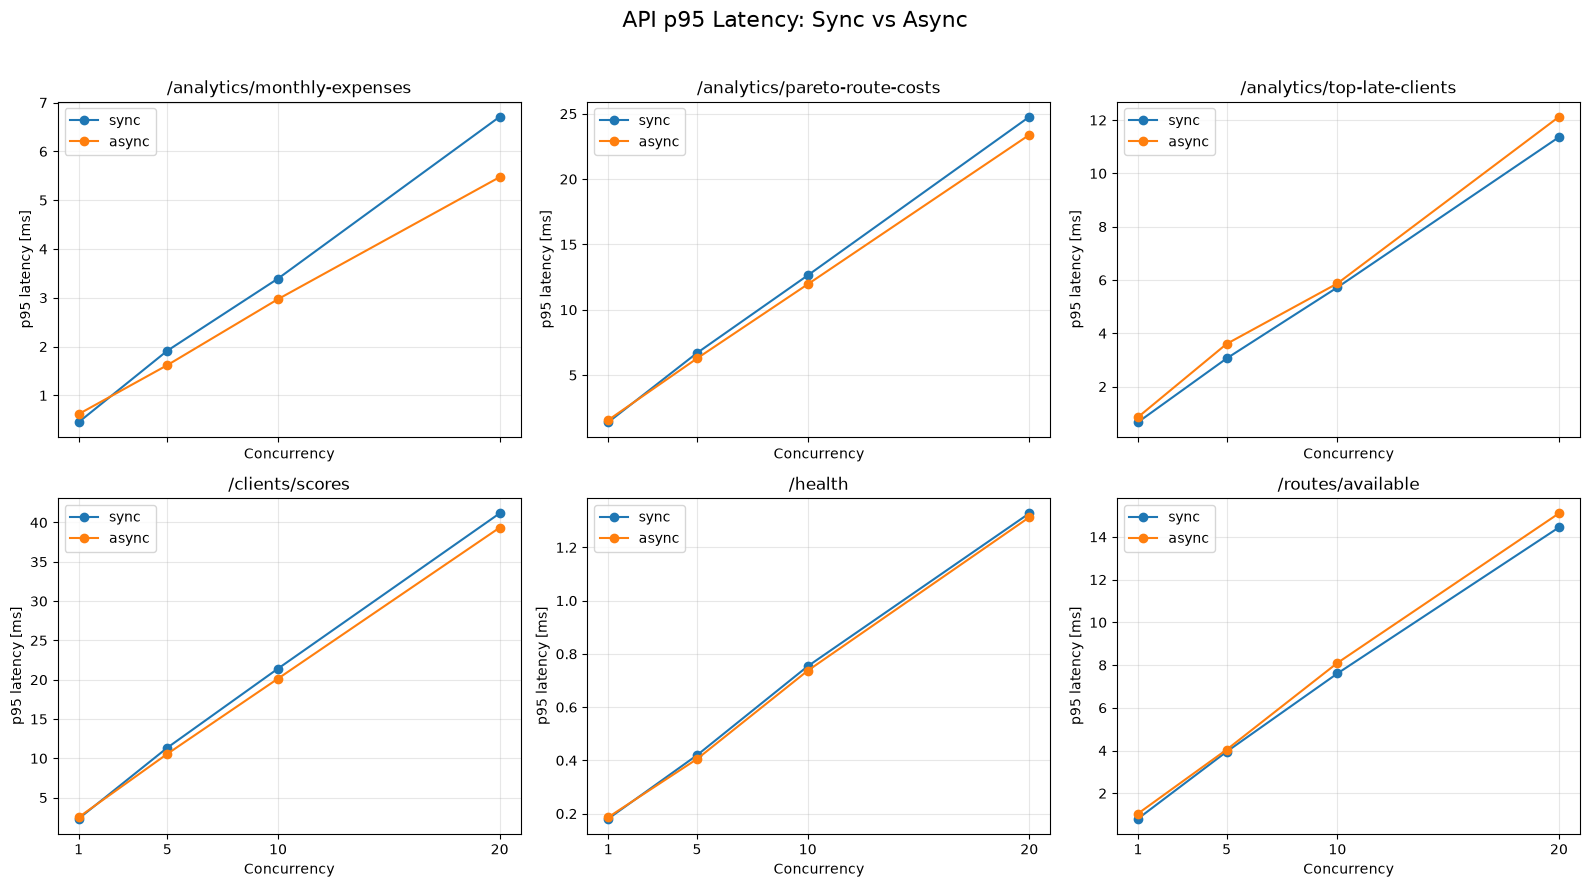

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for ax, endpoint in zip(axes, endpoints):
    endpoint_data = summary[summary["endpoint"] == endpoint]

    for label in ["sync", "async"]:
        data = (
            endpoint_data[endpoint_data["label"] == label]
            .sort_values("concurrency")
        )

        ax.plot(
            data["concurrency"],
            data["p95_ms_mean"],
            marker="o",
            label=label,
        )

    ax.set_title(endpoint)
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("p95 latency [ms]")
    ax.set_xticks([1, 5, 10, 20])
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("API p95 Latency: Sync vs Async", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(
    CHARTS_DIR / "p95_latency.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [35]:
high_load = comparison[
    comparison["concurrency"] == 20
][[
    "endpoint",
    "rps_gain_pct",
    "p95_improvement_pct",
]].copy()

high_load = high_load.sort_values(
    "rps_gain_pct",
    ascending=False,
).reset_index(drop=True)

high_load.round(2)

,endpoint,rps_gain_pct,p95_improvement_pct
0,/analytics/monthly-expenses,31.43,18.43
1,/analytics/pareto-route-costs,8.89,5.58
2,/clients/scores,4.50,4.43
3,/health,0.36,1.10
4,/routes/available,-8.12,-4.55
5,/analytics/top-late-clients,-10.23,-6.70


In [36]:
best = comparison.loc[comparison["rps_gain_pct"].idxmax()]
worst = comparison.loc[comparison["rps_gain_pct"].idxmin()]

print(
    f"Largest throughput gain: "
    f"{best['endpoint']} at c={int(best['concurrency'])}: "
    f"{best['rps_gain_pct']:.1f}%"
)

print(
    f"Largest throughput regression: "
    f"{worst['endpoint']} at c={int(worst['concurrency'])}: "
    f"{worst['rps_gain_pct']:.1f}%"
)

Largest throughput gain: /analytics/monthly-expenses at c=10: 32.1%
Largest throughput regression: /analytics/monthly-expenses at c=1: -23.9%


## Conclusions

The async database migration produced workload-dependent performance changes rather than a universal speedup.

The largest improvement was observed for `/analytics/monthly-expenses`. At concurrency 10, async throughput was about 32% higher than sync, while p95 latency was also lower. At concurrency 20, throughput remained about 31% higher.

`/analytics/pareto-route-costs` and `/clients/scores` showed smaller but consistent gains under concurrent load.

In contrast, `/analytics/top-late-clients` and `/routes/available` performed better with synchronous database access in this benchmark.

At concurrency 1, sync was generally faster, indicating that async does not provide an advantage when there is little or no I/O overlap.

The `/health` endpoint showed nearly identical performance between sync and async at higher concurrency, which supports that the observed differences on database-backed endpoints are related to workload characteristics rather than the server launcher itself.

Overall, asynchronous database access improved scalability for selected endpoints under concurrent load, but the benefit depended on the query and endpoint behavior.